# 🌊 Wave Buoy Data from the U.S. National Data Buoy Center (NDBC)

Data is retrieved from the **National Data Buoy Center (NDBC)**:  
🔗 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

This notebook downloads and visualizes historical wave buoy data, including:

- **Bulk wave parameters**
- **Density energy spectra** (when available)
- **Directional wave spectra** (when available)

📘 **Reference documentation:**
- [NDBC Web Data Guide](https://www.ndbc.noaa.gov/docs/ndbc_web_data_guide.pdf)  
- [Measurement Descriptions & Units](https://www.ndbc.noaa.gov/faq/measdes.shtml)


---


<summary><strong>📥 Downloading Bulk Wave Parameters</strong></summary>

This section downloads time series data (e.g., significant wave height, period, direction) for a given buoy.

- NDBC data files are organized by year.
- File formats and available variables vary across years.
- This script handles inconsistencies and outputs a clean, standardized dataset.

---


<summary><strong>🌊 Downloading Density Energy Spectra</strong></summary>

This section retrieves **density energy spectra** data, stored in yearly files.

- Formats vary (e.g., frequency resolution, date formatting).
- The script processes each year independently but allows plotting across multiple years.
- Only buoys with a `"w"` suffix provide wave spectra. If data is unavailable, an HTTP 404 is raised and skipped.

📘 **More info:** [Wave Spectra Description](https://www.ndbc.noaa.gov/faq/wavespectra.shtml)



---


<summary><strong>🧭 Directional Wave Spectrum Reconstruction</strong></summary>

To reconstruct the directional wave spectrum, multiple coefficient files must be downloaded.

The directional spectrum is:

\[
\begin{align*}
S(f, A) = C_{11}(f) \cdot D(f, A)
\end{align*}
\]

Where:

- \( f \) = frequency (Hz)  
- \( A \) = azimuth angle (°), measured clockwise from true North (direction **waves come from**)  
- \( D(f, A) \) is defined as:

\[
\begin{align*}
D(f, A) = \frac{1}{\pi} \left[ 0.5 + R_1 \cos(A - \alpha_1) + R_2 \cos\left(2(A - \alpha_2)\right) \right]
\end{align*}
\]

### Fourier Coefficients

\[
\begin{align*}
R_1 &= \frac{\sqrt{a_1^2 + b_1^2}}{a_0} \\
R_2 &= \frac{\sqrt{a_2^2 + b_2^2}}{a_0} \\
\alpha_1 &= 270^\circ - \arctan2(b_1, a_1) \\
\alpha_2 &= 270^\circ - 0.5 \cdot \arctan2(b_2, a_2) \pm 180^\circ
\end{align*}
\]

### Notes

- Historical monthly/yearly `R1` and `R2` values are scaled by 100 → multiply by **0.01**
- \( D(f, A) \) may contain **negative values** due to cosine terms.
  - See: *Earle et al., Ocean Engineering (1999)* for methods to handle this
- \( \alpha_2 \) may be adjusted by 180° to minimize its difference with \( \alpha_1 \)

📘 **Further Reading:**  
Earle, Steele & Wang (1999). *Use of advanced directional wave spectra analysis methods*. Ocean Engineering, 26(12), 1421–1434.




Buoy 41013: Data found for year 2014
Buoy 41013: Data found for year 2015
Buoy 41013: Data found for year 2016

Data saved to ./data/buoy_data/41013/buoy_41013_combined.csv


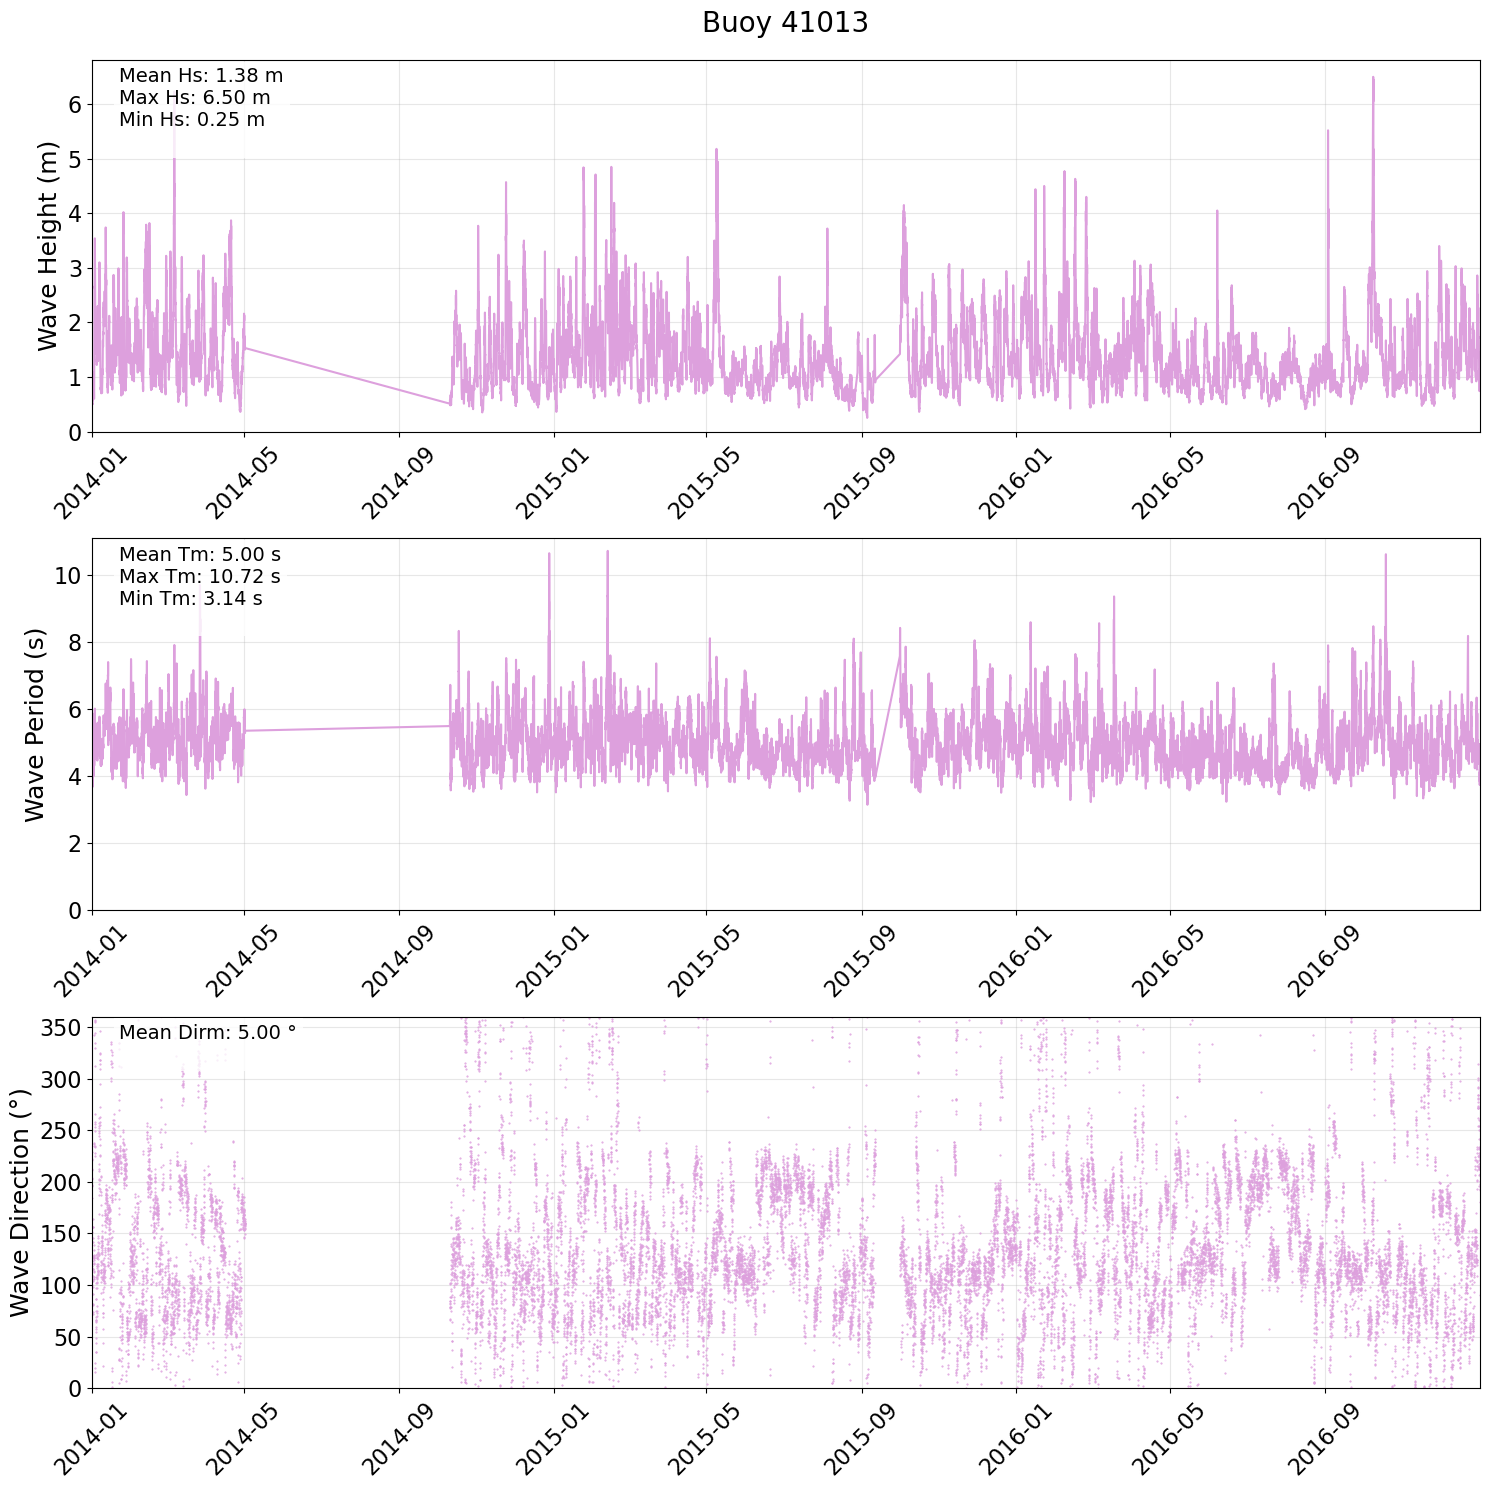

Buoy 41108: Data found for year 2014
Buoy 41108: Data found for year 2015
Buoy 41108: Data found for year 2016

Data saved to ./data/buoy_data/41108/buoy_41108_combined.csv


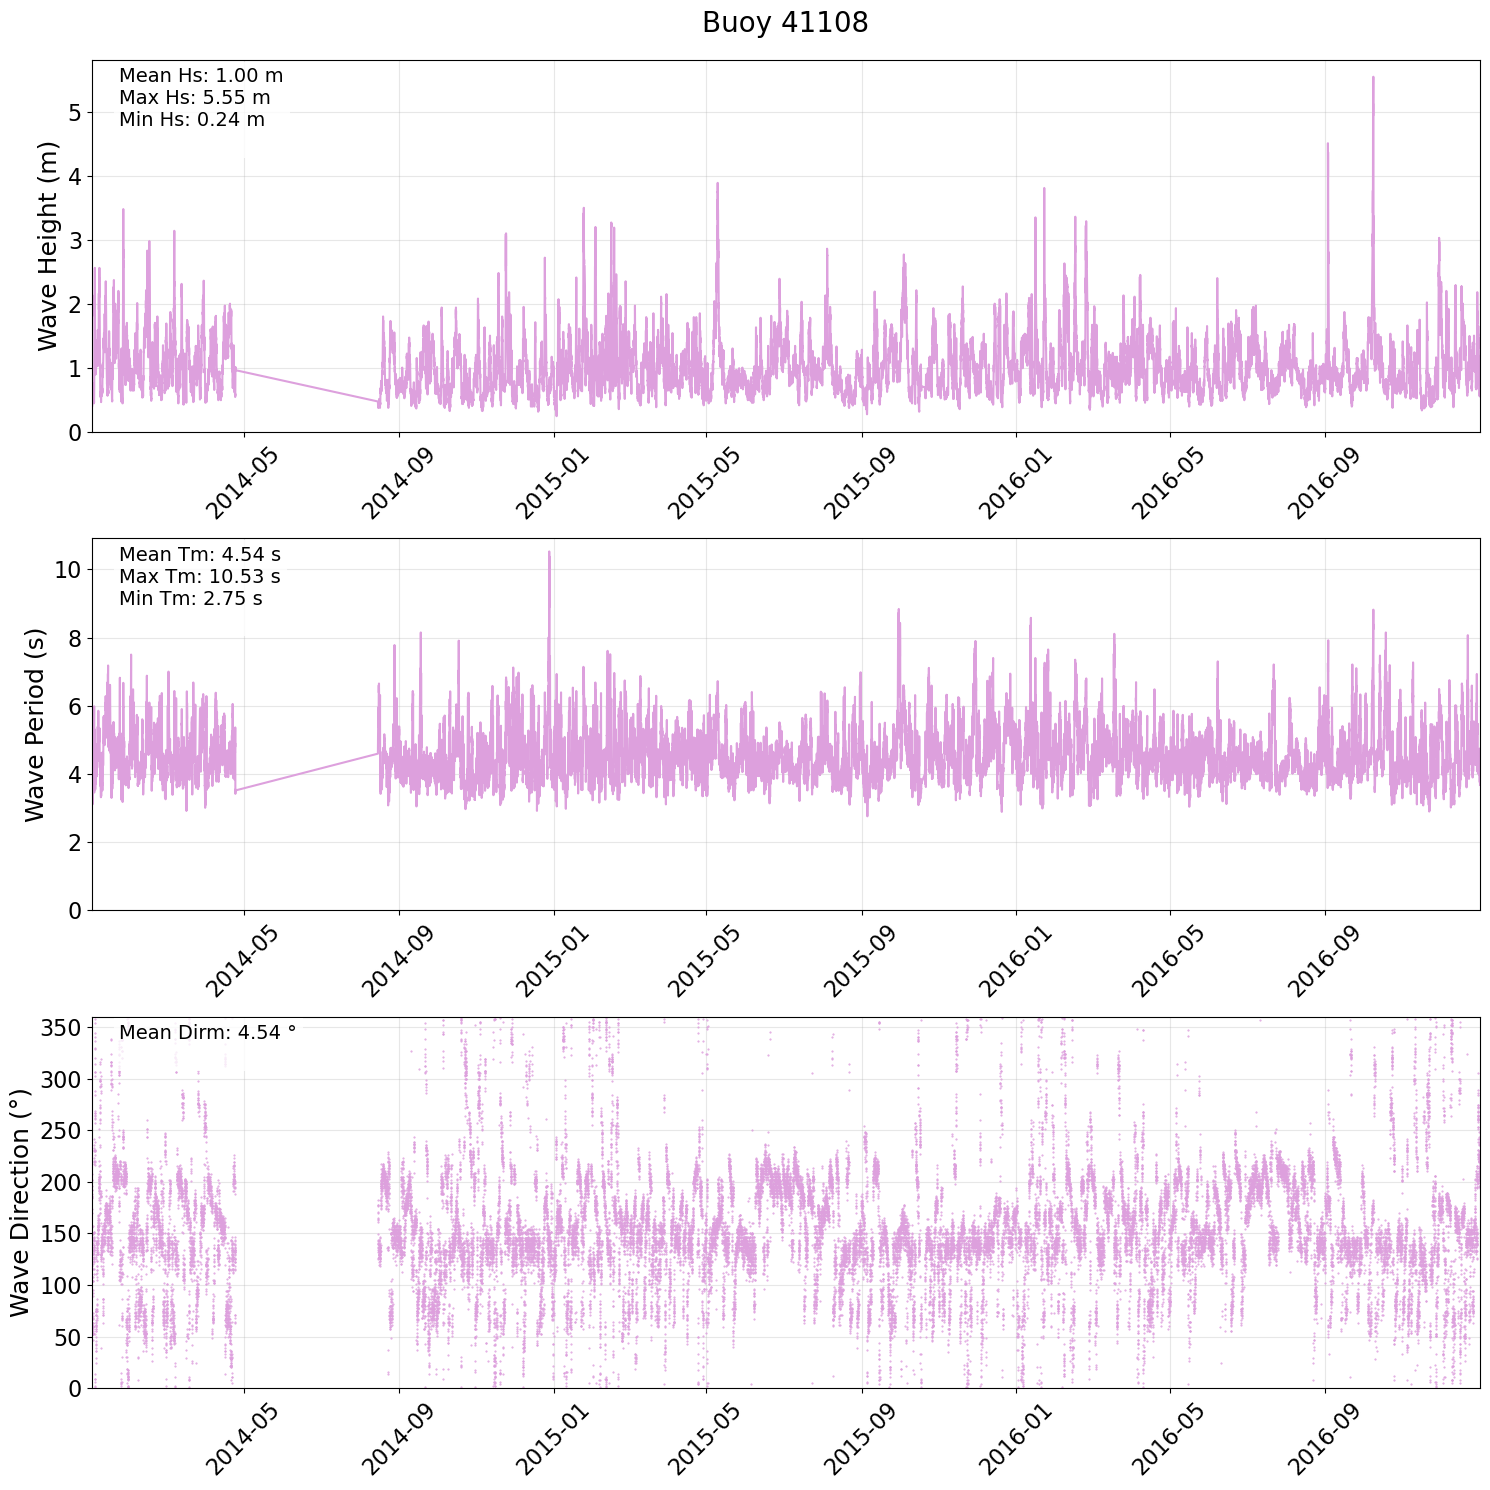

In [1]:
## Downloading and plotting Buoy Bulk parameters time-series
%matplotlib inline
from utils.NDBC_download import process_buoy
from utils.NDBC_plot import plot_wvht_timeseries
buoy_ids = ['41013','41108']

for buoy_id in buoy_ids:
    process_buoy(buoy_id, start_year=2014, end_year=2016,base_dir='./data/buoy_data')
    plot_wvht_timeseries(buoy_id,base_dir='./data/buoy_data')




In [8]:
# Comparing bulk parameters time-series for multiple buoys

from utils.NDBC_plot import plot_multiple_buoys_wvht
buoy_ids = ['41013','41108']
plot_multiple_buoys_wvht(buoy_ids, base_dir='./data/buoy_data')


TypeError: plot_multiple_buoys_wvht() got an unexpected keyword argument 'base_dir'